<a href="https://colab.research.google.com/github/MamoMGD1/ML_101/blob/main/notebooks/Section01_Supervised_Learning/Chapter03_Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ENSEMBLE LEARNING**

## **Condorcet's Jury Theorem**

The roots of **Ensemble Learning** can be traced back to an idea from the 18th century known as **Condorcet’s Jury Theorem**.  

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S01_C03/condorcet.jpg" width="300">
</div>

**Image Credit:** [Original Website](https://en.wikipedia.org/wiki/Condorcet%27s_jury_theorem)

The theorem states:  

> *If each juror (or decision-maker) is slightly better than random guessing, then the probability that the majority vote is correct approaches 1 as the number of jurors increases.*

Why does this matter for machine learning?  
- Each *juror* in the theorem is like a **weak learner** in ML — not very accurate on its own, but a little better than random chance.  
- By letting many such learners “vote” together, we can dramatically improve the reliability of the final decision.  
- The key is that individual errors tend to cancel out, while the *collective wisdom* grows stronger.  

This is exactly the foundation of **ensemble learning**: instead of relying on a single imperfect model, we combine many slightly better-than-random models to achieve high accuracy.  

As you will see in the simple simulation below, even with a tiny bias toward the correct answer, a large group almost always makes the right decision. Run the code multiple times and notice how consistently the majority comes out correct — a direct demonstration of Condorcet’s idea in action. You could then set the `bias = 0` to see how the results will fall back to random.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def jury_vote(n_jurors, bias=0.0):
    """
    Simulate a jury of n_jurors where each juror has a slight bias toward the correct answer.
    """
    votes = np.random.rand(n_jurors) + bias  # Each juror's chance of making the correct decision
    mean_vote = np.mean(votes)
    final_decision = 1 if mean_vote >= 0.5 else 0
    return final_decision

# Parameters
num_trials = 10
jurors_per_trial = 1_000_000 # A large number of jurors
bias = 0.001  # Small positive bias towards the truth (Set to 0 and see the difference)

# Run multiple trials
results = [jury_vote(jurors_per_trial, bias) for _ in range(num_trials)]

print(f"Correct decisions: {np.sum(results)} out of {num_trials} trials")

Correct decisions: 10 out of 10 trials


## **Parallel vs Sequential Ensembles**

The idea behind **ensemble learning** is simple yet powerful: combine multiple models to produce a stronger overall predictor. But *how* these models are built and combined can differ dramatically — and that difference gives us two big families of ensemble methods: **Bagging** and **Boosting**.

- **Bagging** (*Bootstrap Aggregating*)  
  In Bagging, multiple models (often called *base learners*) are trained **independently and in parallel**. Each learner sees a slightly different version of the training data — typically by drawing random *bootstrap samples* (random sampling *with replacement*).  
  Because they’re trained independently, one learner’s errors don’t affect another’s training. In the end, all predictions are combined, usually by voting (for classification) or averaging (for regression).  
  Famous example: **Random Forests** (an ensemble of decision trees using bagging and feature randomness).

- **Boosting**  
  Boosting takes a different path: the models are trained **sequentially**, not independently.  
  Here, each new learner tries to *fix* the mistakes made by the previous ones — focusing more on the data points that were misclassified or poorly predicted.  
  Over time, these *weak learners* are chained together into a single strong model.  
  Famous examples: **AdaBoost**, **Gradient Boosting Machines (GBM)**, and **XGBoost**.

In short:
- **Bagging** reduces *variance* by averaging many diverse learners.
- **Boosting** reduces *bias* by letting each learner improve on the last.

Together, these two strategies show how we can get the best of both worlds: more robust, more accurate models that often outperform any single model alone.

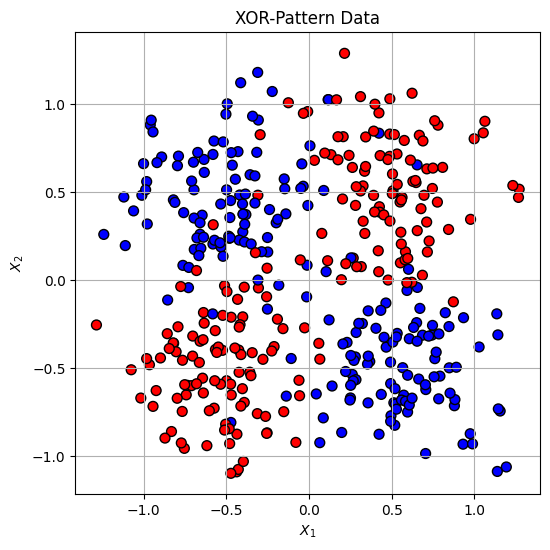

In [3]:
def generate_challenging_data(n_samples=400, noise=0.3, random_state=42):
    np.random.seed(random_state)

    # Generate data in 4 clusters arranged in a checkerboard/XOR pattern
    n_per_cluster = n_samples // 4

    # Create 4 clusters
    clusters = []
    labels = []

    # Cluster 1: bottom-left (class 0)
    clusters.append(np.random.randn(n_per_cluster, 2) * noise + [-0.5, -0.5])
    labels.append(np.zeros(n_per_cluster))

    # Cluster 2: bottom-right (class 1)
    clusters.append(np.random.randn(n_per_cluster, 2) * noise + [0.5, -0.5])
    labels.append(np.ones(n_per_cluster))

    # Cluster 3: top-left (class 1)
    clusters.append(np.random.randn(n_per_cluster, 2) * noise + [-0.5, 0.5])
    labels.append(np.ones(n_per_cluster))

    # Cluster 4: top-right (class 0)
    clusters.append(np.random.randn(n_per_cluster, 2) * noise + [0.5, 0.5])
    labels.append(np.zeros(n_per_cluster))

    X = np.vstack(clusters)
    y = np.hstack(labels).astype(int)

    # Shuffle
    idx = np.random.permutation(len(y))
    return X[idx], y[idx]

# Generate
X, y = generate_challenging_data()

# Plot
plt.figure(figsize=(6, 6))
colors = np.where(y == 1, 'blue', 'red')
plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolor='k', s=50)
plt.title('XOR-Pattern Data')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.grid(True)
plt.show()

## **Bagging (Bootstrap Aggregating)**

As we can see above, not all problems can be solved by a single simple model. Many real-world datasets are noisy, non-linear, and complex — making it difficult for one learner to capture the full picture.  

**Bagging**, short for **Bootstrap Aggregating**, provides a powerful way to overcome this. Instead of relying on a single model, Bagging creates an *ensemble* of weak learners and combines their outputs.  

Here’s how it works step by step:  
1. **Bootstrap Sampling**: From the original training set, we draw multiple random subsets **with replacement**. Each subset (called a bootstrap sample) will be slightly different from the others.  
2. **Train Weak Learners**: A separate weak model is trained on each bootstrap sample. Each learner sees only part of the data, so they capture different aspects of the problem.  
3. **Aggregate Predictions**:  
   - For **classification**, we use **majority voting** (mode of the predictions).  
   - For **regression**, we use the **average** (mean of the predictions).  

This simple idea has two major benefits:  
- **Variance Reduction**: While a single weak learner may overfit or underfit, averaging across many learners smooths out their mistakes.  
- **Robustness**: Outliers or noisy data points are less influential because they don’t dominate all bootstrap samples.  

---

### **An analogy to Build Intuition**

Imagine trying to teach a group of people to recognize elephants in images. If each person studies the **entire elephant**, they might get overwhelmed — tusks, trunk, ears, feet, and tail are a lot of details to process at once.  

But if you split the task:  
- One person focuses only on trunks.  
- Another learns ears.  
- Another looks at tails.  
- Another studies the flat feet.  

Individually, they aren’t reliable:  
- A zebra might trick the “tail expert.”  
- A bat might fool the “ear expert.”  

But when the image really *is* an elephant, almost all of them — trunk, ears, feet, tail — will vote *elephant*. By combining their votes, the group produces a decision that is far more accurate than any individual alone.  

This is exactly how **Bagging** works in machine learning: each weak learner has a limited and imperfect view, but together, their aggregated vote creates a powerful and reliable predictor. Below you can see this idea implemented in code. But let's now discuss what those **weak learners** should be.

In [4]:
from sklearn.utils import resample
from scipy.stats import mode

class EnsembleBagging:
    def __init__(self, n, learner_fn, data_per_bootstrap, task="classification"):
        """
        n: number of bootstrap models
        learner_fn: callable that returns a fresh learner (e.g., lambda: DecisionTreeClassifier())
        data_per_bootstrap: number of samples per bootstrap
        task: "classification" or "regression"
        """
        assert task in ["classification", "regression"], "task must be 'classification' or 'regression'"
        self.n = n
        self.learner_fn = learner_fn
        self.data_per_bootstrap = data_per_bootstrap
        self.task = task
        self.models = []

    def fit(self, X, y):
        self.models = []  # reset models
        for i in range(self.n):
            # Bootstrap sample
            X_bs, y_bs = resample(X, y, n_samples=self.data_per_bootstrap, replace=True, random_state=i)

            # Create and fit model
            model = self.learner_fn(i)
            model.fit(X_bs, y_bs)
            self.models.append(model)

    def predict(self, X):
        # Collect predictions from all learners
        predictions = np.array([model.predict(X) for model in self.models])

        if self.task == "classification":
            # Majority vote
            majority_votes = mode(predictions, axis=0, keepdims=False)[0]
            return majority_votes.flatten()
        else:  # regression
            # Average prediction
            return np.mean(predictions, axis=0)

### **Decision Tree**

A **Decision Tree** is one of the most intuitive machine learning models — it works much like the way we solve problems in everyday life: by asking a sequence of simple questions.  

At its core, the algorithm is a clever version of “20 Questions Game”:  

- At each **node**, the tree asks: *Which feature, and at what threshold, will split the data into the purest groups possible?*  
- For numerical features, it tries different cut-off points.  
- For categorical features, it checks splits based on categories.  
- The “best” split is the one that makes the groups more **homogeneous** — using measures like **Gini Impurity** or **Information Gain**.  
- The process repeats **recursively**, creating new branches until:  
  - all samples in a node belong to one class, or  
  - the maximum depth (or another stopping rule) is reached.  

The result is a **tree of rules**: each branch corresponds to a condition, and each **leaf node** represents a final prediction.  

---

#### **Simple Analogy**  

Imagine you’re deciding whether to go outside today, you would ask yourself:  

1️⃣ *Is it raining?*  
- If **yes** → *Stay home.*  
- If **no** → keep going.  

2️⃣ *Is it very hot?*  
- If **yes** → *Go to the beach.*  
- If **no** → keep going.  

3️⃣ *Is it cold?*  
- If **yes** → *Wear a jacket and go for a walk.*  
- If **no** → *Perfect day for the park!*  

Just like that, a complex decision gets broken into simple yes/no questions, until you land on a clear outcome.  

This ability to **divide a problem into smaller, more manageable decisions** is what makes Decision Trees so powerful:  

- They’re **fast to train**.  
- They’re **interpretable** (you can literally read the rules).  
- They handle both **numerical and categorical data**.  

And while a single tree can sometimes overfit or be unstable, their simplicity and flexibility make them ideal **weak learners** for Ensemble Methods like **Bagging** and **Random Forests** — where many trees together create a strong, robust model.

---

#### **Expected Behavior on Diabetes**

Suppose we want to predict whether a person is **at risk of diabetes (Yes/No)** using these features:

* **Age** (numerical)
* **Gender** (categorical: Male/Female)
* **Fasting Blood Sugar** (numerical)

**Step 1 — Root Node:**
The algorithm checks *all possible splits* across all features:

* For **Age**, it might test thresholds like 25, 30, 35, … and for each threshold, compute how much the split improves class purity.
* For **Gender**, it would test: *“Male in one group, Female in the other”*.
* For **Fasting Blood Sugar**, it tries thresholds like 100, 110, 120, etc.

Let’s say it finds that:

* Splitting by **Age > 30** improves purity a bit (say 65% correct grouping).
* Splitting by **Gender** doesn’t help much (maybe 45%).
* Splitting by **Fasting Blood Sugar > 126 mg/dL** is far more powerful (75% of samples end up correctly grouped).

So, the **first node** will split on **Fasting Blood Sugar > 126 mg/dL**.

**Step 2 — Left Branch (FBS > 126):**
Now the algorithm looks *within this group only* (people with high fasting sugar) and asks again:

* Does **Age** help separate them further?
* Does **Gender** add value?

Suppose within this group, older patients (>50) are almost always at risk, while younger ones sometimes aren’t. Then the branch splits further by **Age > 50**.

**Step 3 — Right Branch (FBS ≤ 126):**
Here, most people are healthy, but not all. The algorithm repeats the same check:

* Maybe **Age > 40** improves purity further (since even with normal fasting sugar, older patients may still have diabetes risk).
* Gender might not add much here, so it gets ignored.

So this branch might split on **Age > 40**.

**Stopping conditions:**
The splitting continues until:

* Nodes become **pure** (only “Yes” or only “No”), or
* The tree hits constraints (e.g. max depth, min samples per leaf).

---

**Final Behavior (Prediction):**
When we give a **new test patient**, the decision path is like following a flowchart:

Example:

* New patient: Age = 55, Gender = Male, Fasting Blood Sugar = 140.
* The tree checks the **root node**: FBS > 126? → Yes → go left.
* Next node: Age > 50? → Yes → follow left again.
* Leaf Node: “Diabetes Risk = Yes”.

So the model doesn’t just average things — it follows the **rules learned during training**, step by step, until it reaches a leaf.


F1 Score (Harmonic mean of precision & recall): 0.9230769230769231



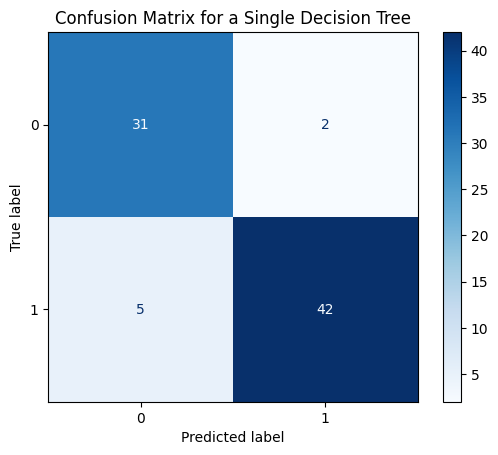

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

class DecisionTreeClassifier:
    def __init__(self, max_depth=None, min_samples_split=2, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.tree = None

    class Node:
        """Represents a node in the decision tree"""
        def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
            self.feature = feature      # Feature index to split on
            self.threshold = threshold  # Threshold value for the split
            self.left = left            # Left child node
            self.right = right          # Right child node
            self.value = value          # Class value if leaf node

    def _gini_impurity(self, y):
        """
        Calculate Gini Impurity: measures how 'pure' a group is.
        Gini = 1 - sum(p_i^2) where p_i is proportion of class i
        """
        if len(y) == 0:
            return 0
        proportions = np.bincount(y) / len(y)
        return 1 - np.sum(proportions ** 2)

    def _information_gain(self, y_parent, y_left, y_right):
        """
        Calculate how much a split improves purity.
        Information Gain = Gini(parent) - weighted_average(Gini(children))
        """
        weight_left = len(y_left) / len(y_parent)
        weight_right = len(y_right) / len(y_parent)

        gain = self._gini_impurity(y_parent) - (
            weight_left * self._gini_impurity(y_left) +
            weight_right * self._gini_impurity(y_right)
        )
        return gain

    def _split(self, X, y, feature, threshold):
        """Split data based on feature and threshold"""
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        return X[left_mask], X[right_mask], y[left_mask], y[right_mask]

    def _best_split(self, X, y):
        """
        Find the best split: which feature and threshold maximizes information gain?
        """
        best_gain = -1
        best_feature = None
        best_threshold = None

        n_features = X.shape[1]

        # Try all features
        for feature in range(n_features):
            # Get unique values as potential thresholds
            thresholds = np.unique(X[:, feature])

            # Try all thresholds for this feature
            for threshold in thresholds:
                # Split the data
                _, _, y_left, y_right = self._split(X, y, feature, threshold)

                # Skip if split creates empty node
                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                # Calculate information gain
                gain = self._information_gain(y, y_left, y_right)

                # Keep track of best split
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def _build_tree(self, X, y, depth=0):
        """
        Recursively build the tree by asking questions at each node.
        Stops when:
        - All samples belong to one class (pure node) or
        - Max depth is reached or
        - Not enough samples to split further
        """
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # Stopping conditions (as described in the documentation)
        if (depth >= self.max_depth if self.max_depth else False) or \
           n_classes == 1 or \
           n_samples < self.min_samples_split:
            # Create leaf node with majority class
            leaf_value = Counter(y).most_common(1)[0][0]
            return self.Node(value=leaf_value)

        # Find best split (the best question to ask)
        best_feature, best_threshold, best_gain = self._best_split(X, y)

        # If no good split found, create leaf
        if best_feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return self.Node(value=leaf_value)

        # Split the data based on the best question
        X_left, X_right, y_left, y_right = self._split(X, y, best_feature, best_threshold)

        # Recursively build left and right subtrees
        left_subtree = self._build_tree(X_left, y_left, depth + 1)
        right_subtree = self._build_tree(X_right, y_right, depth + 1)

        # Create internal node with the split decision
        return self.Node(
            feature=best_feature,
            threshold=best_threshold,
            left=left_subtree,
            right=right_subtree
        )

    def fit(self, X, y):
        """Train the decision tree"""
        if self.random_state is not None:
            np.random.seed(self.random_state)
        self.tree = self._build_tree(X, y)
        return self

    def _predict_sample(self, x, node):
        """
        Predict a single sample by following the decision path.
        """
        # If leaf node, return the class value
        if node.value is not None:
            return node.value

        # Otherwise, follow the appropriate branch based on the feature value
        if x[node.feature] <= node.threshold:
            return self._predict_sample(x, node.left)
        else:
            return self._predict_sample(x, node.right)

    def predict(self, X):
        """Predict class labels for all samples"""
        return np.array([self._predict_sample(x, self.tree) for x in X])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a single custom Decision Tree
tree = DecisionTreeClassifier(max_depth=10, random_state=42)
tree.fit(X_train, y_train)

# Predict on test set
y_pred = tree.predict(X_test)

# Evaluate performance
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)
print(f'\nF1 Score (Harmonic mean of precision & recall): {f1}\n')

# --- Plot confusion matrix ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for a Single Decision Tree')
plt.show()


F1 Score (Harmonic mean of precision & recall): 0.924731182795699



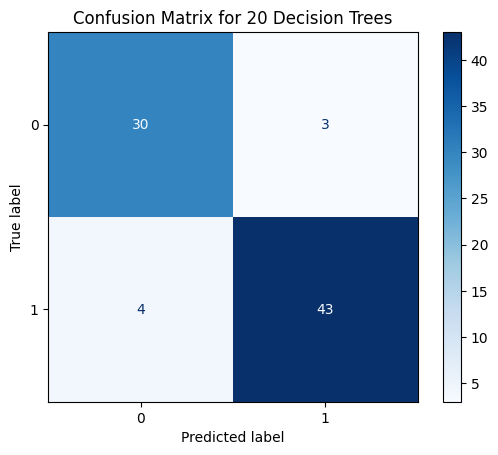

In [6]:
n_trees = 20

# Create the ensemble with custom decision trees
ensemble = EnsembleBagging(
    n=n_trees,
    learner_fn=lambda i: DecisionTreeClassifier(max_depth=10, random_state=i),
    data_per_bootstrap=len(X_train)
)

# Train it
ensemble.fit(X_train, y_train)

# Predict new samples
y_pred = ensemble.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)
print(f'\nF1 Score (Harmonic mean of precision & recall): {f1}\n')

# --- Plot confusion matrix ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix for {n_trees} Decision Trees')
plt.show()

### **Random Forest**

If you look back at the code we just wrote, we built an `Ensemble Bagging` class and used it to combine 20 different decision trees together. But did you notice something strange? Even after aggregating multiple trees, the performance doesn’t really improve much.  

**Why is that?**  
The problem lies in how **Decision Trees** behave: they are very strict in their decisions. No matter how many bootstraps you feed them, they often end up choosing the **same features** at the top of the tree. The only small difference might be in the **threshold values**, but the overall structure is very similar.

Think of it in our **diabetes** example: no matter which bootstrap sample we give the tree, it will almost always find that **blood fasting sugar** provides the largest information gain and place it at the root.  
That means all our trees look nearly the same, making the “ensemble” far less diverse than we want.

---

### **How Random Forest fixes this**
A **Random Forest** is a clever extension of Bagging. It not only gives each tree a different bootstrap sample of the rows but also forces each split inside the tree to choose from a **random subset of features**.  

This extra randomness breaks the strictness of decision trees:
* One tree might start with **blood fasting sugar**,  
* Another might start with **BMI**,  
* Another with **age**,  
even if all of them had the same dataset.

By doing this:
* Trees get **different perspectives** of the dataset.  
* Each tree grows **deep and complex**, often overfitting on its own.  
* But when we combine their outputs (majority vote for classification, average for regression), the overfitting cancels out, and the result is far more robust.


F1 Score: 0.9347826086956522



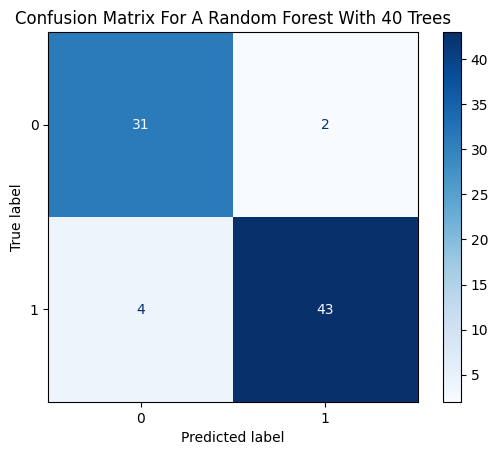

In [7]:
class RandomForestTree(DecisionTreeClassifier):
    """
    A Decision Tree modified for Random Forest:
    at each split, only considers a random subset of features.
    """
    def __init__(self, max_depth=None, min_samples_split=2, max_features=None, random_state=None):
        super().__init__(max_depth=max_depth, min_samples_split=min_samples_split, random_state=random_state)
        self.max_features = max_features

    def _best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None

        n_features = X.shape[1]

        # Randomly choose subset of features for this split
        if self.max_features is None or self.max_features > n_features:
            feature_indices = range(n_features)
        else:
            feature_indices = np.random.choice(n_features, size=self.max_features, replace=False)

        # Same as original, but only loop through chosen subset
        for feature in feature_indices:
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                _, _, y_left, y_right = self._split(X, y, feature, threshold)
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                gain = self._information_gain(y, y_left, y_right)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

# Random Forest via Bagging
n_trees = 40
random_forest = EnsembleBagging(
    n=n_trees,
    learner_fn=lambda i: RandomForestTree(max_depth=10, max_features=int(np.sqrt(X.shape[1]))),
    data_per_bootstrap=len(X_train)
)

# Predict new samples
random_forest.fit(X_train, y_train)
y_pred = random_forest.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f'\nF1 Score: {f1}\n')
# --- Plot confusion matrix ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix For A Random Forest With {n_trees} Trees')
plt.show()

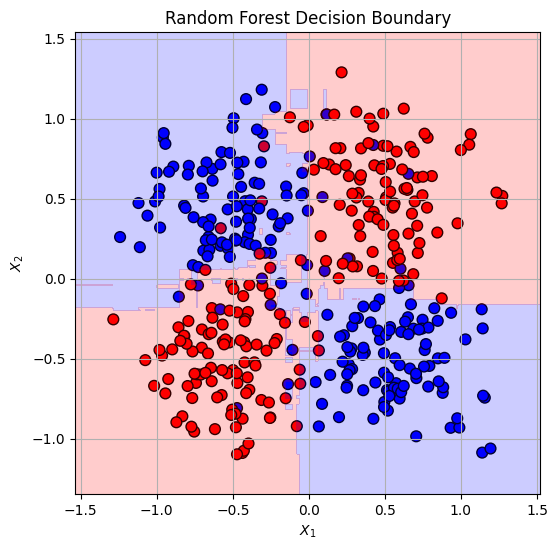

In [8]:
plt.figure(figsize=(6, 6))
colors = np.where(y == 1, 'blue', 'red')
plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolor='k', s=60)

# Plot the decision boundary
# Create a grid over the plot
x_min, x_max = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
y_min, y_max = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict for every point in the grid
Z = random_forest.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the filled contour
plt.contourf(xx, yy, Z, alpha=0.2, levels=1, colors=['red', 'blue'])

# Labels and styling
plt.title('Random Forest Decision Boundary')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.xlim(x_min,x_max)
plt.ylim(y_min,y_max)
plt.grid(True)
plt.show()

## **Boosting**

There’s a catch with simple **Bagging**:
Yes, by training lots of weak learners on random bootstraps and aggregating their votes, we can reduce **variance** and get more stable predictions — but Bagging does **not** directly tackle the **bias** of the learners.

If every single weak learner makes the **same mistake**, then no amount of voting will fix that. Remember that our aim is not only to reduce variance (be more consistent about the answer), but also to reduce bias (move closer to the *right* answer).

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S01_C03/archery.png" width="500">
</div>

This is where **Boosting** comes in:
Boosting takes the idea of an ensemble further by forcing the weak learners to **learn from each other’s mistakes**.
Each new learner in the sequence pays extra attention to the samples that were **misclassified** by the previous ones.

---

### **A Metaphor**

Imagine you ask **100 older people**, who don’t watch cartoons, *“What color do you think someone named **Shrek** would be?”*
Almost all of them will confidently say **orange** or **brown**, because they assume Shrek is just a person with typical human skin color.

When you take a **majority vote**, you’ll get a very **consistent** answer — but it’s consistently **wrong**.
You reduced **variance** (most of the voters agree), but the **bias** (they don’t know Shrek is actually a green ogre!) means you’ll never get the right answer.

A better approach would be:
Ask one person first, tell the next person whether that answer was right or wrong, and let them adjust their guess.
Each person tries to fix the mistake of the one before — eventually, someone might hit on *“green monster”* and everyone learns!

This is the heart of **Boosting**: not just lots of guesses, but **sequential guesses that learn from each other’s errors**.

**The same way,**

You won’t improve much by just solving random questions over and over.
Instead, you take a test, check your answers, find which topics you struggled with, study them harder, and then take another test.
That cycle — focusing on mistakes — is exactly how Boosting works.

---

### **How it works**

A classic Boosting algorithm is **AdaBoost (Adaptive Boosting)**.
Here’s the process step by step:

1. **Initialize weights**
   Start with all training samples equally important:
   $$
   w_i^{(1)} = \frac{1}{N}
   $$

2. **Train a weak learner**
   Fit a simple model (often a shallow decision tree).

3. **Measure its performance**
   Compute the **weighted error rate**:
   $$
   \epsilon_m = \frac{\sum_{i: y_i \neq h_m(x_i)} w_i^{(m)}}{\sum_{i=1}^{N} w_i^{(m)}}
   $$

   * If the learner does better than random guessing, $\epsilon_m < 0.5$.
   * If it does worse, it’s essentially useless.

4. **Give it a voting power**
   The more accurate the learner, the stronger its influence:
   $$
   \alpha_m = \frac{1}{2} \ln\left(\frac{1 - \epsilon_m}{\epsilon_m}\right)
   $$

   * Low error → large $\alpha_m$ (strong vote).
   * Random guessing → $\alpha_m \approx 0$ (no influence).

5. **Update sample weights**

   * Misclassified samples get **upweighted** (harder cases matter more).  
   $w_i^{(m+1)} = w_i^{(m)} \cdot e^{\alpha_m}$
   * Correctly classified samples get **downweighted** (easy cases matter less).  
   $w_i^{(m+1)} = w_i^{(m)} \cdot e^{-\alpha_m}$

6. **Repeat**
   Train the next weak learner on this reweighted dataset. Each new learner is “pulled” toward the mistakes of the previous ones.

7. **Final prediction**
   Combine all weak learners with their weighted votes:
   $$
   H(x) = \text{sign}\left(\sum_{m=1}^{M} \alpha_m , h_m(x)\right)
   $$

---

### **Key difference**

* **Bagging** trains each learner **independently** and treats them equally (parallel).
* **Boosting** trains learners **sequentially**, with each one focusing on the **harder cases** left behind.

Boosting can transform extremely weak models (like shallow trees) into a strong, high-performance ensemble — and in practice it powers some of the most successful ML algorithms today (AdaBoost, Gradient Boosting, XGBoost, LightGBM).


F1 Score: 0.9361702127659575



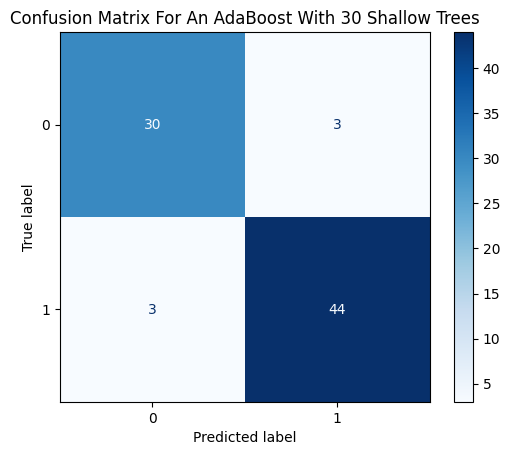

In [10]:
class AdaBoostClassifier:
    def __init__(self, n_estimators=50, learning_rate=1.0, random_state=42):
        """
        Parameters:
        -----------
        n_estimators : int
            Number of weak learners to train sequentially
        learning_rate : float
            Shrinks the contribution of each classifier (like a step size)
        random_state : int
            Random seed for reproducibility
        """
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.alphas = []  # Voting power of each learner
        self.learners = []  # The weak learners themselves

    def fit(self, X, y):
        """
        Train weak learners sequentially, each focusing on previous mistakes.
        """
        n_samples = X.shape[0]

        # Initialize: all samples get equal weight
        weights = np.ones(n_samples) / n_samples

        # Convert labels to {-1, 1} for easier math
        y_encoded = np.where(y == 0, -1, 1)

        for m in range(self.n_estimators):
            # Train a weak learner on weighted samples
            seed = None if self.random_state is None else self.random_state + m
            learner = DecisionTreeClassifier(
                max_depth=2,  # Stump: very weak learner
                random_state=seed
            )

            # Sample with replacement based on weights (boosted sampling)
            rng = np.random.RandomState(seed)
            sample_indices = rng.choice(
                n_samples,
                size=n_samples,
                replace=True,
                p=weights
            )

            learner.fit(X[sample_indices], y[sample_indices])
            predictions = learner.predict(X)
            pred_encoded = np.where(predictions == 0, -1, 1)

            # Calculate weighted error: sum of weights where prediction is wrong
            incorrect = (pred_encoded != y_encoded)
            error = np.sum(weights * incorrect) / np.sum(weights)

            # Avoid division by zero or log of zero
            error = np.clip(error, 1e-10, 1 - 1e-10)

            # Calculate voting power: better learners get more say
            alpha = self.learning_rate * 0.5 * np.log((1 - error) / error)

            # Update weights: increase for mistakes, decrease for correct
            weights *= np.exp(alpha * incorrect * 2 - alpha)

            # Normalize weights to sum to 1
            weights /= np.sum(weights)

            # Save this learner and its voting power
            self.learners.append(learner)
            self.alphas.append(alpha)

        return self

    def predict(self, X):
        """
        Weighted majority vote: each learner votes with power alpha.
        """
        # Get all predictions
        learner_preds = np.array([learner.predict(X) for learner in self.learners])

        # Convert to {-1, 1} for weighted sum
        learner_preds = np.where(learner_preds == 0, -1, 1)
        self.alphas = np.array(self.alphas)

        # Weighted vote: sum(alpha * prediction)
        weighted_sum = np.sum(
            self.alphas[:, np.newaxis] * learner_preds,
            axis=0
        )

        # Sign gives us the final class
        predictions = np.where(weighted_sum >= 0, 1, 0)

        return predictions

# Train AdaBoost
n = 30
ada_boost = AdaBoostClassifier(n_estimators=n, learning_rate=1.0, random_state=42)
ada_boost.fit(X_train,y_train)

# Predict on test set
y_pred = ada_boost.predict(X_test)

# Evaluate
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f'\nF1 Score: {f1}\n')
# --- Plot confusion matrix ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix For An AdaBoost With {n} Shallow Trees')
plt.show()

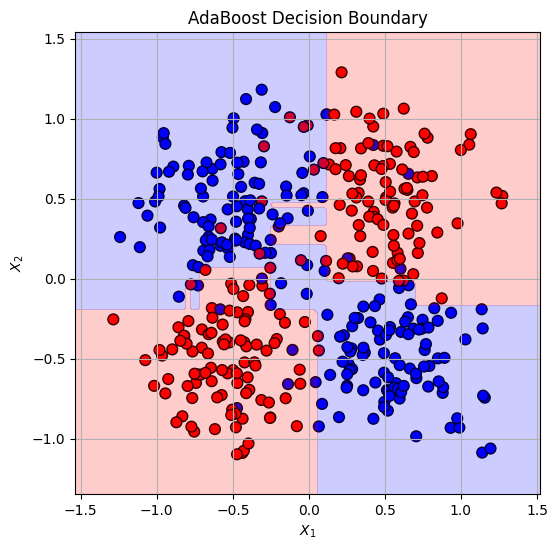

In [11]:
plt.figure(figsize=(6, 6))
colors = np.where(y == 1, 'blue', 'red')
plt.scatter(X[:, 0], X[:, 1], c=colors, edgecolor='k', s=60)

# Plot the decision boundary
# Create a grid over the plot
x_min, x_max = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
y_min, y_max = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

# Predict for every point in the grid
Z = ada_boost.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the filled contour
plt.contourf(xx, yy, Z, alpha=0.2, levels=1, colors=['red', 'blue'])

# Labels and styling
plt.title('AdaBoost Decision Boundary')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.xlim(x_min,x_max)
plt.ylim(y_min,y_max)
plt.grid(True)
plt.show()

## **Closing This Chapter**

Supervised Learning started with a **simple idea**:  teach a model like you’d teach a child with flashcards — *“this is a cat, this is not”*.  
A single learner, like a decision tree, can do surprisingly well. But soon we realized: **one voice alone is limited.**

That’s when ensembles entered the scene.

* With **Bagging**, we learned to ask many learners the same question in parallel. Each one sees the world a little differently, and together their answers average out the noise. Random Forests are the classic example — hundreds of trees, each strong on their own bias, but powerful when they vote as one.

* With **Boosting**, we discovered another path: sequential teamwork. Instead of repeating the same question, each learner **listens to the mistakes** of the one before, paying special attention to what was missed. AdaBoost showed us how even very weak models can, step by step, correct each other until the whole group becomes remarkably strong.

In both cases, the heart of the idea is simple:  
**combine many simple, often linear or fragile learners and the result is a flexible, non-linear, powerful model.**

It’s like moving from one student with a flashlight, to an entire classroom, each shining their light on a different corner of the problem.  
Alone, they stumble. Together, they see.

##🚀 **What's Next?**

> **Unsupervised Learning**

In the next section of this course we're going to see what happens when nobody tells the machine what’s right or wrong. No labels, no answers — just patterns hiding in plain sight. It's time to find the hidden treasure in **unlabeled data**.